In [433]:
import librosa
import numpy as np
import pretty_midi
import soundfile as sf
from scipy import stats
import noisereduce as nr
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.signal import butter, lfilter

In [434]:
song_acc = "FLLS"
tidy_midi = False
min_note_length = "quaver"

acr_to_bpm = {
    "NEICD" :   120,
    "NGHYB" :   97,
    "FLLS"  :   100
}

bpm = acr_to_bpm[song_acc]

input_filename = f"mp3_input/bass_{song_acc}.mp3"
input_cleaned_filename = f"mp3_input/bass_{song_acc}_clean.mp3"

output_std_filename = f"transcribed_output/bass_{song_acc}_std_transcribed.mid"
# output_raw_filename = f"transcribed_output/bass_{song_acc}_raw_transcribed.mid"
# output_filename = f"transcribed_output/bass_{song_acc}_transcribed.mid"

#used for visualisation
seconds_start = 0
seconds_end = 20

y, sr = librosa.load(input_filename, sr=None, mono=True)  # keep original sample rate

### Clean up Bass  
Remove anything outside 40-400Hz

In [435]:
# ----------------------------
# 2. Band-pass filter (40–400 Hz for 4-string bass)
# ----------------------------
def butter_bandpass(lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut=40.0, highcut=400.0, fs=44100, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    return lfilter(b, a, data)

In [436]:
#keep only frequencies which the 4 string bass is capable of

y_band = bandpass_filter(y, lowcut=40.0, highcut=400.0, fs=sr)

sf.write(input_cleaned_filename, y_band, sr)

audio, sr = librosa.load(input_cleaned_filename)
audio_condensed = audio[seconds_start * sr :seconds_end*sr]

In [437]:
crotchet_len = 60/bpm
quaver_len = crotchet_len/2
semiquaver_len = quaver_len/2
minim_len = crotchet_len*2
semibreve_len = minim_len*2
audio_seconds = len(audio)/sr

note_intervals = {
    "semibreve" :   semibreve_len,
    "minim"     :   minim_len,
    "crotchet"  :   crotchet_len,
    "quaver"    :   quaver_len,
    "semiquaver":   semiquaver_len
}

### Convert to Notes

In [438]:
hop_length = 512 # default

In [439]:
# Convert frequencies → MIDI notes
def hz_to_midi(hz):
    if hz <= 0 or np.isnan(hz):
        return None
    return int(round(69 + 12 * np.log2(hz / 440.0)))

### Extract Notes
def extract_notes(audio):
    f0 = librosa.yin(y=audio, fmin=40, fmax=400, sr=sr)
    times = librosa.frames_to_time(np.arange(len(f0)), sr=sr, hop_length=hop_length)
    midi_notes = [hz_to_midi(freq) for freq in f0]

    return midi_notes, times



In [440]:
midi_notes, times = extract_notes(audio)
midi_notes_sample, times_sample = extract_notes(audio_condensed)

### Strum Identification

In [441]:
def peak_trough_dist(peaks, troughs):
    distances = []
    for i, peak in enumerate(peaks):
        # find the first trough that comes after this peak
        following_troughs = troughs[troughs > peak]
        
        next_peak = peaks[min(i+1, len(peaks)-1)]#add check to make sure i can't go beyond end of array
        
        if len(following_troughs) > 0:
            next_trough = following_troughs[0] 
        
            if(next_peak<next_trough):
                distances.append(None) # peak followed by another peak and not a trough
            else:
                distance = next_trough - peak
                distances.append(int(distance))
        else:
            distances.append(None)  # or skip if no trough follows

    return(distances)

def remove_fake_strum_indexes(col_sums, peak_prominence, trough_prominence, max_distance, sample = False):
    peaks, _ = find_peaks(col_sums, prominence=peak_prominence)
    troughs, _ = find_peaks(-col_sums, prominence=trough_prominence)

    peak_trough_distances = peak_trough_dist(peaks, troughs)
    #remove distances which are greater than max distances and get indexes of false strums
    false_strum_distances = [dist if dist != None and dist < max_distance else None for dist in peak_trough_distances]
    false_strum_indexes = [i for i in range(len(false_strum_distances)) if false_strum_distances[i] != None]
    #remove false strums from strum indexes
    strums_indexes = [int(peak) for i, peak in enumerate(peaks) if i not in false_strum_indexes]
    false_strums = [int(peak) for i, peak in enumerate(peaks) if i in false_strum_indexes]

    if sample:
        plt.plot(col_sums)
        plt.plot(false_strums, col_sums[false_strums], "x", color = 'g')
        plt.plot(strums_indexes, col_sums[strums_indexes], "x", color = 'r')
    
    return(strums_indexes)


# sample_col_sums = col_sums_std#[:150]
# remove_fake_strum_indexes(sample_col_sums, peak_prominence=0.1, trough_prominence=0.4, max_distance=15, sample = True)
# # a = col_sums_std[:-1]
# # b = col_sums_std[1:]

# # # db_arr = np.array([10,2,12,15,1,12,1,3])
# # # a = db_arr[:-1]
# # # b = db_arr[1:]

# # # plt.plot(a-b)
# # trough_prominence = 0.4
# # sample_col_sums = col_sums_std#[:150]

# # sample_peaks, _ = find_peaks(sample_col_sums, prominence=peak_prominence)
# # sample_troughs, _ = find_peaks(-sample_col_sums, prominence=trough_prominence)

# # plt.plot(sample_col_sums)
# # plt.plot(sample_troughs, sample_col_sums[sample_troughs], "x", color = 'g')
# # plt.plot(sample_peaks, sample_col_sums[sample_peaks], "x", color = 'r')

# # print(peak_trough_dist(peaks=sample_peaks, troughs=sample_troughs))

In [442]:
def find_strums(audio, peak_prominence = 0.1, trough_prominence = 0.4, max_distance=15, sample= False):
    X = librosa.stft(audio)
    Xdb = librosa.amplitude_to_db(abs(X))

    Xdb_condensed = Xdb[:70] # most of FT space is empty for bass - this is mainly used for visualisation
    #column sums
    col_sums = Xdb_condensed.sum(axis=0)
    #standardize so that the same prominance can be used between songs 
    col_sums_std = (col_sums - col_sums.min()) / (col_sums.max() - col_sums.min())

    strums = remove_fake_strum_indexes(col_sums_std, peak_prominence=peak_prominence, trough_prominence=trough_prominence, max_distance=max_distance, sample = sample)
    return strums
    # peaks_all, _ = find_peaks(col_sums_std, prominence=peak_prominence)
    
    # if sample:
    #     plt.plot(col_sums_std)
    #     plt.plot(peaks_all, col_sums_std[peaks_all], "x", color = 'r')

    # return(peaks_all)

#turn indexes into times 
peaks_all = find_strums(audio)
strums = librosa.frames_to_time(peaks_all, sr=sr, hop_length=512)


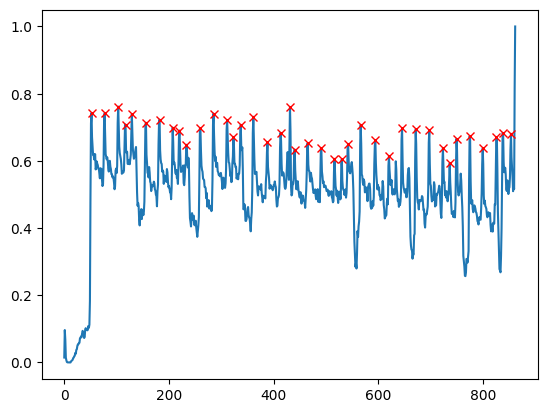

In [443]:
#sample to display
peaks_sample = find_strums(audio_condensed,peak_prominence=0.1, trough_prominence=0.55, sample=True)
strums_sample = librosa.frames_to_time(peaks_sample, sr=sr, hop_length=512)


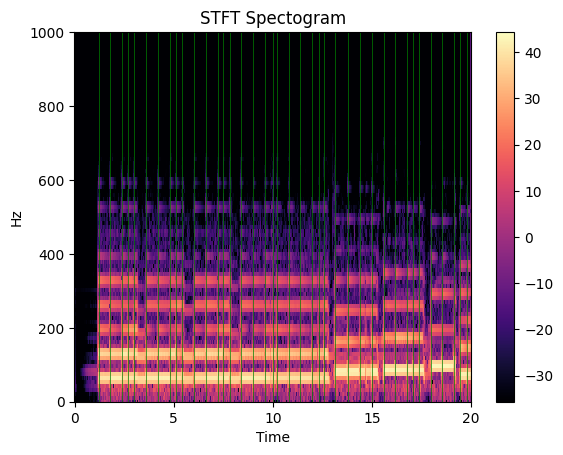

In [444]:
X_sample = librosa.stft(audio_condensed)
Xdb_sample = librosa.amplitude_to_db(abs(X_sample))
librosa.display.specshow(Xdb_sample, sr=sr, x_axis='time', y_axis='hz')
plt.ylim(0, 1000)
plt.title('STFT Spectogram')
plt.colorbar()

for s in strums_sample:
    plt.axvline(x=s, color='g', linewidth=0.5, linestyle="-")

### Strums against Notes

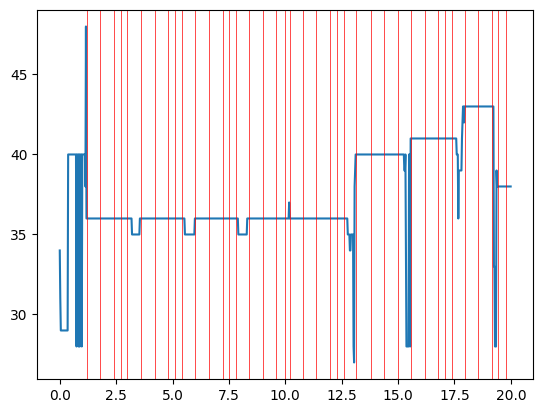

In [445]:

plt.plot(times_sample, midi_notes_sample)

for s in strums_sample:
    plt.axvline(x=s, color='r', linewidth=0.5, linestyle="-")

In [446]:
### Make all notes in a strum equal to the mode
# print(midi_notes_strums[1])

def mode_array(strum_notes):
    mode = stats.mode(strum_notes).mode
    mode_arr = np.full(len(strum_notes), int(mode)) # make array of mode same size as original
    return(mode_arr)

#remove_strum
def remove_strum(strum_notes):
    mode_arr = np.full(len(strum_notes), None)
    return(mode_arr)

def std_strum_notes(strums_all, remove_indexes):
    all_notes = np.array([])
    for i, strum_notes in enumerate(strums_all):
        remove = i in remove_indexes

        if remove:
            mode_arr = remove_strum(strum_notes)
        else:
            mode_arr = mode_array(strum_notes)
        
        all_notes = np.concat([all_notes, mode_arr])
    return(all_notes)

In [447]:
### Split by peak indexes
midi_notes_strums = np.split(midi_notes, peaks_all)

midi_notes_std = std_strum_notes(midi_notes_strums, remove_indexes=[0])

### Turn to Midi

In [448]:
# build midi from sequence of midi notes 
# Build MIDI file
midi = pretty_midi.PrettyMIDI()
bass_program = pretty_midi.instrument_name_to_program("Acoustic Bass")
bass = pretty_midi.Instrument(program=bass_program)

# Group frames into sustained notes
current_note = None
note_start = None

for i, note in enumerate(midi_notes_std):
    if note is not None:
        if current_note is None:  # new note
            current_note = note
            note_start = times[i]
        elif note != current_note or i in peaks_all:  # pitch change → close old note, start new
            bass.notes.append(pretty_midi.Note(
                velocity=100, pitch=current_note,
                start=note_start, end=times[i]
            ))
            current_note = note
            note_start = times[i]
    else:
        if current_note is not None:  # end current note
            bass.notes.append(pretty_midi.Note(
                velocity=100, pitch=current_note,
                start=note_start, end=times[i]
            ))
            current_note = None
            note_start = None

# If song ends with a note still playing
if current_note is not None:
    bass.notes.append(pretty_midi.Note(
        velocity=100, pitch=current_note,
        start=note_start, end=times[-1]
    ))

midi.instruments.append(bass)

### Clean up Midi

In [449]:
instrument = midi.instruments[0]
# instrument = bass

# ----------------------------
# Define helpers
# ----------------------------

def quantize_time(time, interval, pm):
    """Quantize a time value to the nearest grid point."""
    # # Get beat grid from PrettyMIDI
    # beats = pm.get_beats()
    # if len(beats) < 2:
    #     return time  # no tempo info, skip

    # Grid spacing in seconds
    grid = np.arange(0, audio_seconds, note_intervals[interval])
    return grid[np.argmin(np.abs(grid - time))]

if tidy_midi:
    min_length = note_intervals[min_note_length]

    cleaned_notes = []
    for note in instrument.notes:
        # # Keep only notes in 4-string bass range (E1=40 to G4=67 in MIDI numbers)
        # if 40 <= note.pitch <= 67:
        # Remove very short noise notes (< 60 ms)
        if note.end - note.start > min_length:
            # Clamp velocities to a usable range
            note.velocity = min(max(note.velocity, 40), 100)

            # Quantize note start and end to nearest 1/16th note
            quantized_start = quantize_time(note.start, min_note_length, midi)  # quarter-note subdivisions
            quantized_end = quantize_time(note.end, min_note_length, midi)

            # Ensure quantized_end > quantized_start
            if quantized_end <= quantized_start:
                quantized_end = quantized_start + 0.1

            note.start = quantized_start
            note.end = quantized_end

            cleaned_notes.append(note)

    instrument.notes = cleaned_notes


In [450]:
### Save Midi (Standardised)
midi.write(output_std_filename)